##Assignment 4
### Praneel Iralapalle, 240770
---
##Setup and Data Loading

In [16]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# --- Setup and Data Loading ---
dat = pd.read_csv("word-recognition.csv", index_col=0)


sigma = 0.4
alpha = 6

##Exercise 1.1: Importance Sampling

In [17]:
np.random.seed(123)
N = 20000


prop_beta = np.random.normal(0, 1, N)
prop_gamma = np.random.normal(5, 1, N)
prop_theta = np.random.beta(70, 30, N)

log_weights = np.zeros(N)

log_prior_b = stats.norm.logpdf(prop_beta, loc=0, scale=0.5)
log_prior_g = stats.norm.logpdf(prop_gamma, loc=5, scale=0.5)
log_prior_t = stats.beta.logpdf(prop_theta, a=70, b=30)
log_prior = log_prior_b + log_prior_g + log_prior_t

log_prop_b = stats.norm.logpdf(prop_beta, loc=0, scale=1)
log_prop_g = stats.norm.logpdf(prop_gamma, loc=5, scale=1)
log_prop_t = stats.beta.logpdf(prop_theta, a=70, b=30)
log_prop = log_prop_b + log_prop_g + log_prop_t

freq = dat['frequency'].values
rt = dat['rt'].values


for i in range(N):

    meanlog_1 = alpha + prop_beta[i] * freq
    pdf_1 = stats.lognorm.pdf(rt, s=sigma, scale=np.exp(meanlog_1))

    meanlog_2 = prop_gamma[i]
    pdf_2 = stats.lognorm.pdf(rt, s=sigma, scale=np.exp(meanlog_2))

    L_i = prop_theta[i] * pdf_1 + (1 - prop_theta[i]) * pdf_2

    log_lik = np.sum(np.log(L_i + 1e-300))

    log_weights[i] = log_lik + log_prior[i] - log_prop[i]

weights = np.exp(log_weights - np.max(log_weights))
weights = weights / np.sum(weights)

post_indices = np.random.choice(N, size=N//2, p=weights, replace=True)
post_beta_is = prop_beta[post_indices]
post_gamma_is = prop_gamma[post_indices]
post_theta_is = prop_theta[post_indices]

##Exercise 1.2: Markov Chain Monte Carlo

In [18]:
nsamp_mcmc = 20000
nburn = 5000


chain = np.zeros((nsamp_mcmc, 3))
chain[0] = [0, 5, 0.7]

def log_posterior(b, g, t, data_freq, data_rt):

    if t <= 0 or t >= 1:
        return -np.inf

    log_prior_val = (stats.norm.logpdf(b, 0, 0.5) +
                     stats.norm.logpdf(g, 5, 0.5) +
                     stats.beta.logpdf(t, 70, 30))

    meanlog_1 = alpha + b * data_freq
    pdf_1 = stats.lognorm.pdf(data_rt, s=sigma, scale=np.exp(meanlog_1))

    meanlog_2 = g
    pdf_2 = stats.lognorm.pdf(data_rt, s=sigma, scale=np.exp(meanlog_2))

    L_i = t * pdf_1 + (1 - t) * pdf_2
    log_lik = np.sum(np.log(L_i + 1e-300))

    return log_lik + log_prior_val

# Metropolis-Hastings evolution
for i in range(1, nsamp_mcmc):
    curr = chain[i-1]

    prop_b = np.random.normal(curr[0], 0.1)
    prop_g = np.random.normal(curr[1], 0.1)
    prop_t = np.random.normal(curr[2], 0.05)

    curr_post = log_posterior(curr[0], curr[1], curr[2], freq, rt)
    prop_post = log_posterior(prop_b, prop_g, prop_t, freq, rt)

    # Acceptance criteria
    if np.log(np.random.uniform()) < (prop_post - curr_post):
        chain[i] = [prop_b, prop_g, prop_t]
    else:
        chain[i] = curr

post_beta_mcmc = chain[nburn:, 0]

##Exercise 1.3: Graphical Comparison

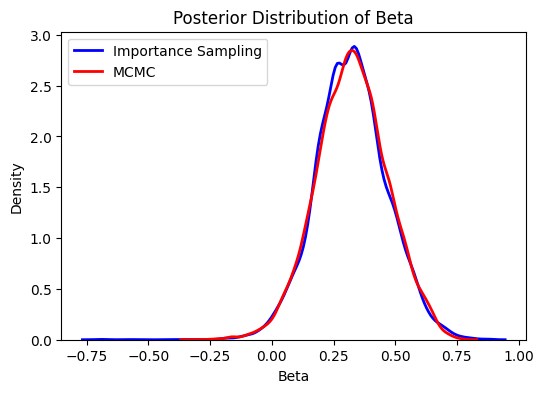

In [30]:
plt.figure(figsize=(6, 4))
sns.kdeplot(post_beta_is, color="blue", linewidth=2, label="Importance Sampling")
sns.kdeplot(post_beta_mcmc, color="red", linewidth=2, label="MCMC")
plt.title("Posterior Distribution of Beta")
plt.xlabel("Beta")
plt.ylabel("Density")
plt.legend(loc="upper left")
plt.show()

## Exercise 1.4

In this model, the mean log-reaction time ($\mu_i$) is calculated as $\alpha + \beta \times \text{frequency}$. Since high-frequency words are coded as $1$, a negative value for $\beta$ would naturally decrease $\mu_i$, indicating a faster recognition time. Consequently, for the data to support the lexical-access hypothesis, the posterior distribution for $\beta$ needs to be heavily concentrated below zero.

---

## Exercise  1.5

The $\theta$ parameter acts as a metric for participant attention. It essentially measures the probability that a subject is actively engaged in the experiment. A higher estimate for $\theta$ means the participant was genuinely focused and completing the task properly, rather than just clicking at random.

##Part 2: Base Setup

In [20]:
np.random.seed(42)
true_mu = 800
true_var = 100
y = np.random.normal(loc=true_mu, scale=np.sqrt(true_var), size=500)
n = len(y)

def gradient(mu, sigma_val, y, n, m, s, a, b):
    grad_mu = (((n * mu) - np.sum(y)) / (sigma_val**2)) + ((mu - m) / (s**2))
    grad_sigma = ((n / sigma_val) -
                  (np.sum((y - mu)**2) / (sigma_val**3)) +
                  ((sigma_val - a) / (b**2)))
    return np.array([grad_mu, grad_sigma])

def V(mu, sigma_val, y, n, m, s, a, b):
    if sigma_val <= 0:
        return np.inf
    nlpd = -(np.sum(stats.norm.logpdf(y, loc=mu, scale=sigma_val)) +
             stats.norm.logpdf(mu, loc=m, scale=s) +
             stats.norm.logpdf(sigma_val, loc=a, scale=b))
    return nlpd

# Core Hamiltonian Monte Carlo Engine
def HMC(y, n, m, s, a, b, step, L, initial_q, nsamp, nburn):
    mu_chain = np.full(nsamp, np.nan)
    sigma_chain = np.full(nsamp, np.nan)
    reject = 0

    mu_chain[0] = initial_q[0]
    sigma_chain[0] = initial_q[1]

    for i in range(nsamp - 1):
        q = np.array([mu_chain[i], sigma_chain[i]])
        p = np.random.normal(0, 1, len(q))

        current_q = q.copy()
        current_p = p.copy()

        current_V = V(current_q[0], current_q[1], y, n, m, s, a, b)
        current_T = np.sum(current_p**2) / 2

        for _ in range(L):
            p = p - (step / 2) * gradient(q[0], q[1], y, n, m, s, a, b)
            q = q + step * p
            p = p - (step / 2) * gradient(q[0], q[1], y, n, m, s, a, b)

        proposed_q = q
        proposed_p = p

        if proposed_q[1] <= 0:
            accept_prob = 0
        else:
            proposed_V = V(proposed_q[0], proposed_q[1], y, n, m, s, a, b)
            proposed_T = np.sum(proposed_p**2) / 2

            energy_diff = current_V + current_T - proposed_V - proposed_T

            if energy_diff > 0:
                accept_prob = 1.0
            else:
                accept_prob = np.min([1.0, np.exp(energy_diff)])

        if not np.isnan(accept_prob) and np.random.uniform(0, 1) < accept_prob:
            mu_chain[i+1] = proposed_q[0]
            sigma_chain[i+1] = proposed_q[1]
        else:
            reject += 1
            mu_chain[i+1] = mu_chain[i]
            sigma_chain[i+1] = sigma_chain[i]

    posteriors = pd.DataFrame({'mu_chain': mu_chain[nburn:], 'sigma_chain': sigma_chain[nburn:]})
    posteriors['sample_id'] = range(1, len(posteriors) + 1)
    return posteriors


##Exercise 2.1: Base HMC Posterior

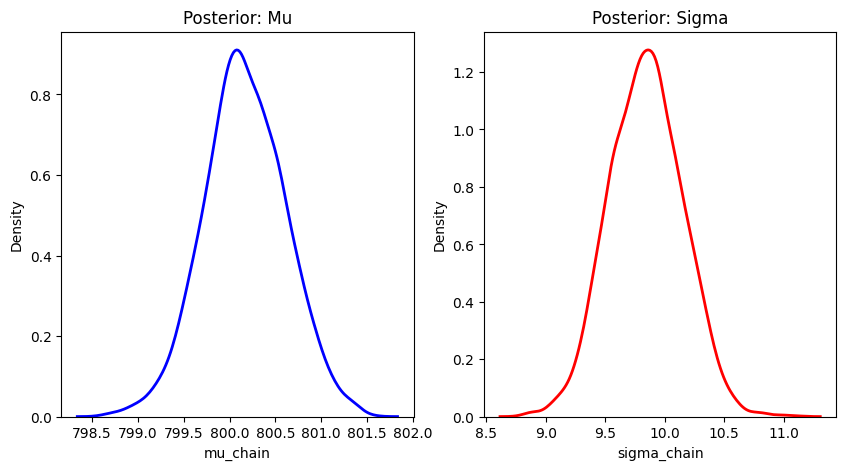

In [21]:
df_posterior = HMC(y=y, n=n, m=1000, s=20, a=10, b=2,
                   step=0.02, L=12, initial_q=[1000, 11], nsamp=6000, nburn=2000)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.kdeplot(df_posterior['mu_chain'], color="blue", linewidth=2, ax=axes[0])
axes[0].set_title("Posterior: Mu")

sns.kdeplot(df_posterior['sigma_chain'], color="red", linewidth=2, ax=axes[1])
axes[1].set_title("Posterior: Sigma")
plt.show()

##Exercise 2.2: Sensitivity to total number of samples

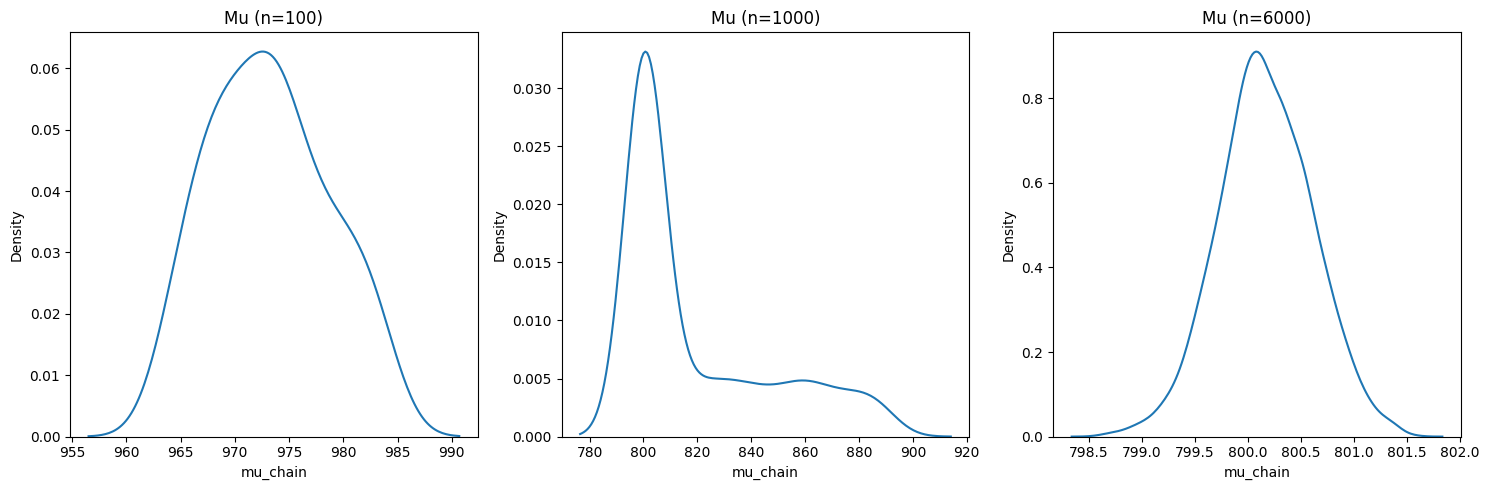

In [22]:
df_100 = HMC(y=y, n=n, m=1000, s=20, a=10, b=2, step=0.02, L=12, initial_q=[1000, 11], nsamp=100, nburn=33)
df_1000 = HMC(y=y, n=n, m=1000, s=20, a=10, b=2, step=0.02, L=12, initial_q=[1000, 11], nsamp=1000, nburn=333)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.kdeplot(df_100['mu_chain'], ax=axes[0]).set_title("Mu (n=100)")
sns.kdeplot(df_1000['mu_chain'], ax=axes[1]).set_title("Mu (n=1000)")
sns.kdeplot(df_posterior['mu_chain'], ax=axes[2]).set_title("Mu (n=6000)")
plt.tight_layout()
plt.show()

##Exercise 2.3 & 2.4: Step-Size Parameters

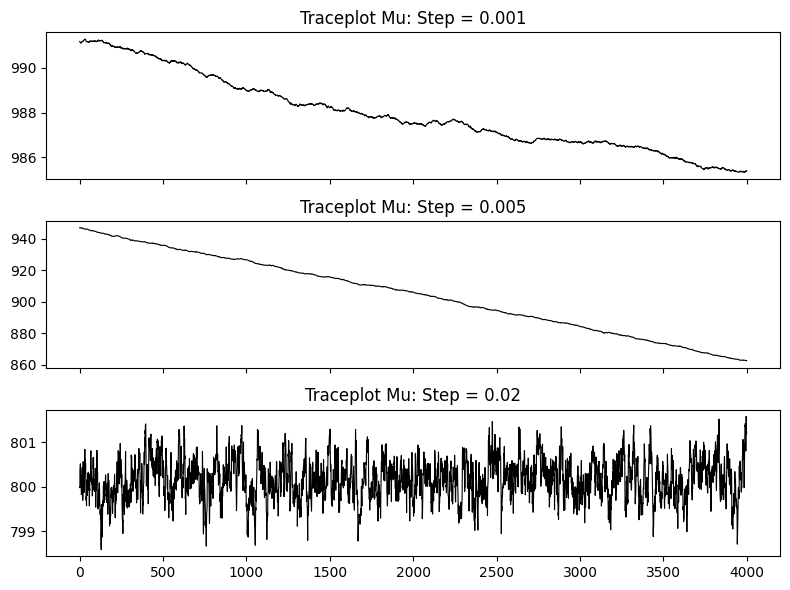

In [26]:
df_step1 = HMC(y=y, n=n, m=1000, s=20, a=10, b=2, step=0.001, L=12, initial_q=[1000, 11], nsamp=6000, nburn=2000)
df_step5 = HMC(y=y, n=n, m=1000, s=20, a=10, b=2, step=0.005, L=12, initial_q=[1000, 11], nsamp=6000, nburn=2000)

fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=True)
axes[0].plot(df_step1['mu_chain'], color='black', linewidth=0.8)
axes[0].set_title("Traceplot Mu: Step = 0.001")

axes[1].plot(df_step5['mu_chain'], color='black', linewidth=0.8)
axes[1].set_title("Traceplot Mu: Step = 0.005")

axes[2].plot(df_posterior['mu_chain'], color='black', linewidth=0.8)
axes[2].set_title("Traceplot Mu: Step = 0.02")
plt.tight_layout()
plt.show()

### Interpretation (Exercise 2.4)
Visual inspection of the chain with a step size of `0.001` shows extreme autocorrelation. Instead of a rapidly fluctuating "fuzzy caterpillar" traceplot (indicating good mixing), the plot looks like a slow, drifting wave. This proves the sampler is taking overly cautious, tiny steps and is failing to explore the target distribution efficiently.

##Exercise 2.5: Prior Sensitivity for Mu

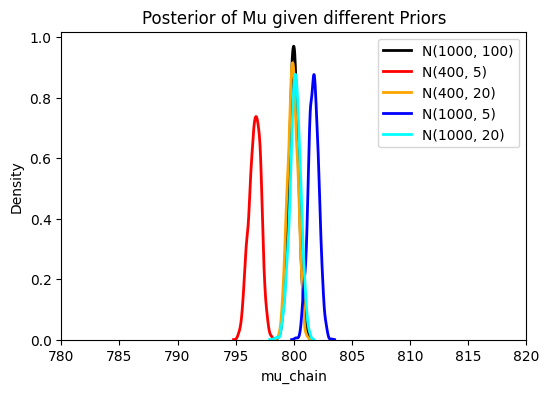

In [28]:
prior_args = {'y': y, 'n': n, 'a': 10, 'b': 2, 'step': 0.02, 'L': 12, 'initial_q': [800, 11], 'nsamp': 3000, 'nburn': 1000}
prior_1 = HMC(**prior_args, m=400, s=5)
prior_2 = HMC(**prior_args, m=400, s=20)
prior_3 = HMC(**prior_args, m=1000, s=5)
prior_4 = HMC(**prior_args, m=1000, s=20)
prior_5 = HMC(**prior_args, m=1000, s=100)

plt.figure(figsize=(6, 4))
sns.kdeplot(prior_5['mu_chain'], color="black", linewidth=2, label="N(1000, 100)")
sns.kdeplot(prior_1['mu_chain'], color="red", linewidth=2, label="N(400, 5)")
sns.kdeplot(prior_2['mu_chain'], color="orange", linewidth=2, label="N(400, 20)")
sns.kdeplot(prior_3['mu_chain'], color="blue", linewidth=2, label="N(1000, 5)")
sns.kdeplot(prior_4['mu_chain'], color="cyan", linewidth=2, label="N(1000, 20)")

plt.title("Posterior of Mu given different Priors")
plt.xlim(780, 820)
plt.ylabel("Density")
plt.legend()
plt.show()

### Interpretation (Exercise 2.5)
When **s** (standard deviation) is large (e.g., **s=100**), the prior is "weak" or uninformative. The data overrides it easily, and the posterior centers neatly around the true mean (800). When **s** is very small (e.g., **s=5**), the prior is highly confident. If the assumed mean **m** is far off (like **m=400** or **1000**), the posterior is forcefully pulled away from the true data mean, proving that strong, incorrectly specified priors heavily bias Bayesian models.